# Human Activity Recognition Project

This notebook analyzes smartphone sensor data to predict human activities.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

## 1. Load the Data

In [8]:
!ls

 drive	 __MACOSX   sample_data  'UCI HAR Dataset'  'UCI HAR Dataset.zip'


In [9]:
!unzip -o 'UCI HAR Dataset.zip'

Archive:  UCI HAR Dataset.zip
  inflating: UCI HAR Dataset/.DS_Store  
  inflating: __MACOSX/UCI HAR Dataset/._.DS_Store  
  inflating: UCI HAR Dataset/activity_labels.txt  
  inflating: __MACOSX/UCI HAR Dataset/._activity_labels.txt  
  inflating: UCI HAR Dataset/features.txt  
  inflating: __MACOSX/UCI HAR Dataset/._features.txt  
  inflating: UCI HAR Dataset/features_info.txt  
  inflating: __MACOSX/UCI HAR Dataset/._features_info.txt  
  inflating: UCI HAR Dataset/README.txt  
  inflating: __MACOSX/UCI HAR Dataset/._README.txt  
  inflating: UCI HAR Dataset/test/Inertial Signals/body_acc_x_test.txt  
  inflating: __MACOSX/UCI HAR Dataset/test/Inertial Signals/._body_acc_x_test.txt  
  inflating: UCI HAR Dataset/test/Inertial Signals/body_acc_y_test.txt  
  inflating: __MACOSX/UCI HAR Dataset/test/Inertial Signals/._body_acc_y_test.txt  
  inflating: UCI HAR Dataset/test/Inertial Signals/body_acc_z_test.txt  
  inflating: __MACOSX/UCI HAR Dataset/test/Inertial Signals/._body_acc_z_t

In [11]:
# Load feature names
features = pd.read_csv('UCI HAR Dataset/features.txt', sep='\s+', header=None)
feature_names = features[1].tolist()

# Load activity labels
activities = pd.read_csv('UCI HAR Dataset/activity_labels.txt', sep='\s+', header=None)
activity_labels = dict(zip(activities[0], activities[1]))

print("Number of features:", len(feature_names))
print("\nActivities:")
for key, value in activity_labels.items():
    print(f"{key}: {value}")

Number of features: 561

Activities:
1: WALKING
2: WALKING_UPSTAIRS
3: WALKING_DOWNSTAIRS
4: SITTING
5: STANDING
6: LAYING


In [13]:
# Load training data
X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None)
X_train.columns = feature_names
y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt', header=None, names=['activity'])

# Load test data
X_test = pd.read_csv('UCI HAR Dataset/test/X_test.txt', sep='\s+', header=None)
X_test.columns = feature_names
y_test = pd.read_csv('UCI HAR Dataset/test/y_test.txt', header=None, names=['activity'])

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (7352, 561)
Test set shape: (2947, 561)


## 2. Exploratory Data Analysis

In [14]:
# Check for missing values
print("Missing values in training data:", X_train.isnull().sum().sum())
print("Missing values in test data:", X_test.isnull().sum().sum())

Missing values in training data: 0
Missing values in test data: 0


In [15]:
# Look at basic statistics
print("Basic statistics:")
print(X_train.describe())

Basic statistics:
       tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  \
count        7352.000000        7352.000000        7352.000000   
mean            0.274488          -0.017695          -0.109141   
std             0.070261           0.040811           0.056635   
min            -1.000000          -1.000000          -1.000000   
25%             0.262975          -0.024863          -0.120993   
50%             0.277193          -0.017219          -0.108676   
75%             0.288461          -0.010783          -0.097794   
max             1.000000           1.000000           1.000000   

       tBodyAcc-std()-X  tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  \
count       7352.000000       7352.000000       7352.000000       7352.000000   
mean          -0.605438         -0.510938         -0.604754         -0.630512   
std            0.448734          0.502645          0.418687          0.424073   
min           -1.000000         -0.999873         -1.000000    

In [16]:
# Check min and max values
print(f"Min value in dataset: {X_train.min().min()}")
print(f"Max value in dataset: {X_train.max().max()}")
print("\nData is normalized between -1 and 1")

Min value in dataset: -1.0
Max value in dataset: 1.0

Data is normalized between -1 and 1


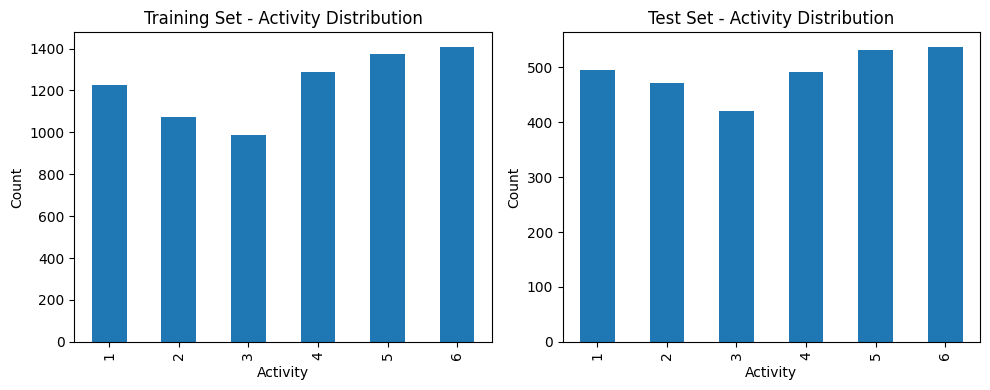


Class distribution in training set:
activity
1    1226
2    1073
3     986
4    1286
5    1374
6    1407
Name: count, dtype: int64


In [17]:
# Plot class distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
y_train['activity'].value_counts().sort_index().plot(kind='bar')
plt.title('Training Set - Activity Distribution')
plt.xlabel('Activity')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
y_test['activity'].value_counts().sort_index().plot(kind='bar')
plt.title('Test Set - Activity Distribution')
plt.xlabel('Activity')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

print("\nClass distribution in training set:")
print(y_train['activity'].value_counts().sort_index())

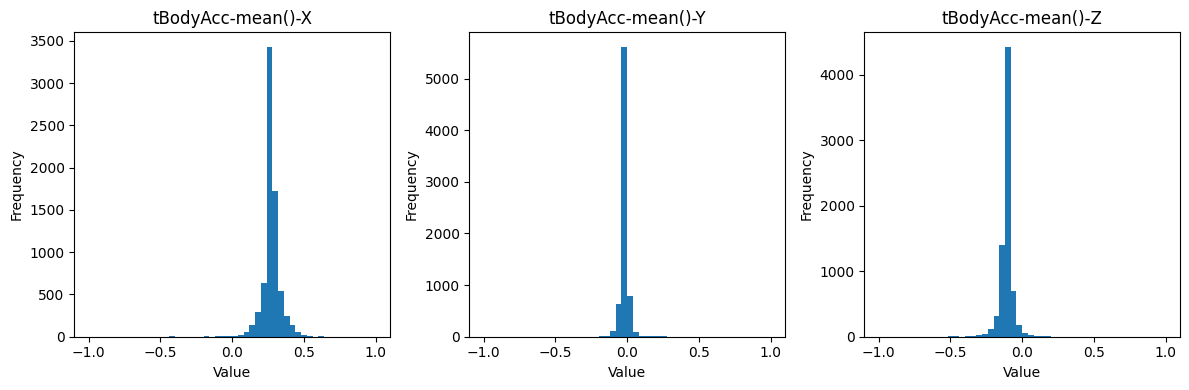

In [18]:
# Look at some feature distributions
sample_features = ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z']

plt.figure(figsize=(12, 4))
for i, feature in enumerate(sample_features, 1):
    plt.subplot(1, 3, i)
    plt.hist(X_train[feature], bins=50)
    plt.title(feature)
    plt.xlabel('Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

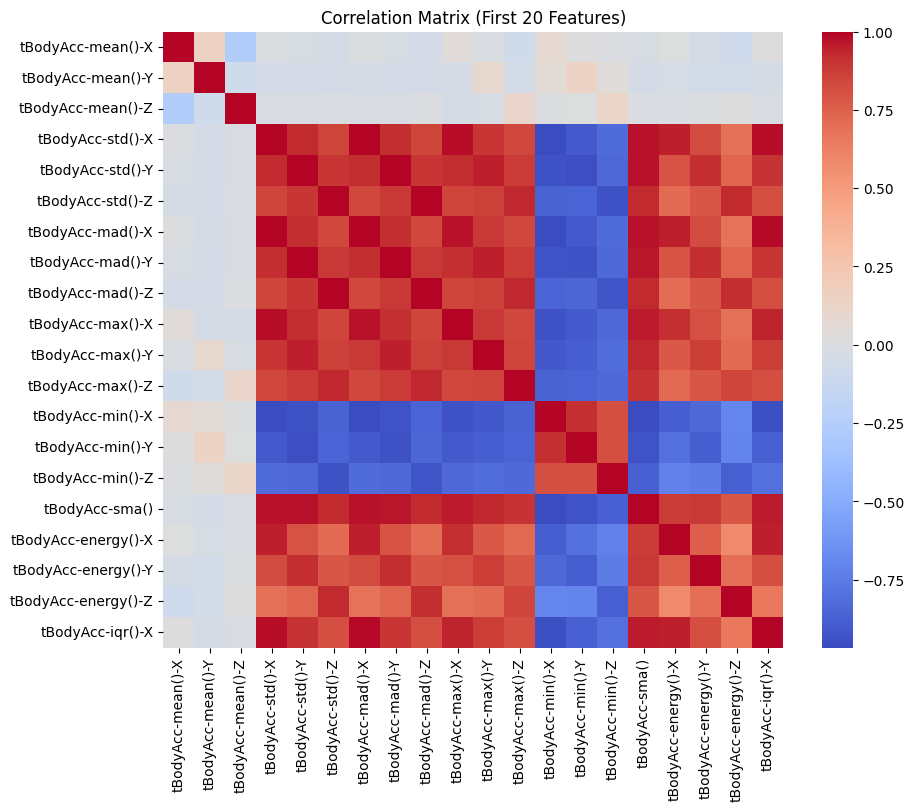

In [19]:
# Check correlation between some features
sample_cols = X_train.iloc[:, :20]
corr = sample_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Matrix (First 20 Features)')
plt.show()

## 3. Model Training

Let's try different models and compare them.

In [20]:
# Prepare labels (convert to 0-indexed)
y_train_labels = y_train['activity'].values - 1
y_test_labels = y_test['activity'].values - 1

### Model 1: Random Forest

In [21]:
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train_labels)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test_labels, rf_pred)
print(f"Random Forest Accuracy: {rf_acc:.4f}")

Training Random Forest...
Random Forest Accuracy: 0.9257


In [22]:
# Try with more trees
print("\nTrying with 200 trees...")
rf_model2 = RandomForestClassifier(n_estimators=200, max_depth=30, random_state=42)
rf_model2.fit(X_train, y_train_labels)

rf_pred2 = rf_model2.predict(X_test)
rf_acc2 = accuracy_score(y_test_labels, rf_pred2)
print(f"Random Forest (200 trees) Accuracy: {rf_acc2:.4f}")


Trying with 200 trees...
Random Forest (200 trees) Accuracy: 0.9257


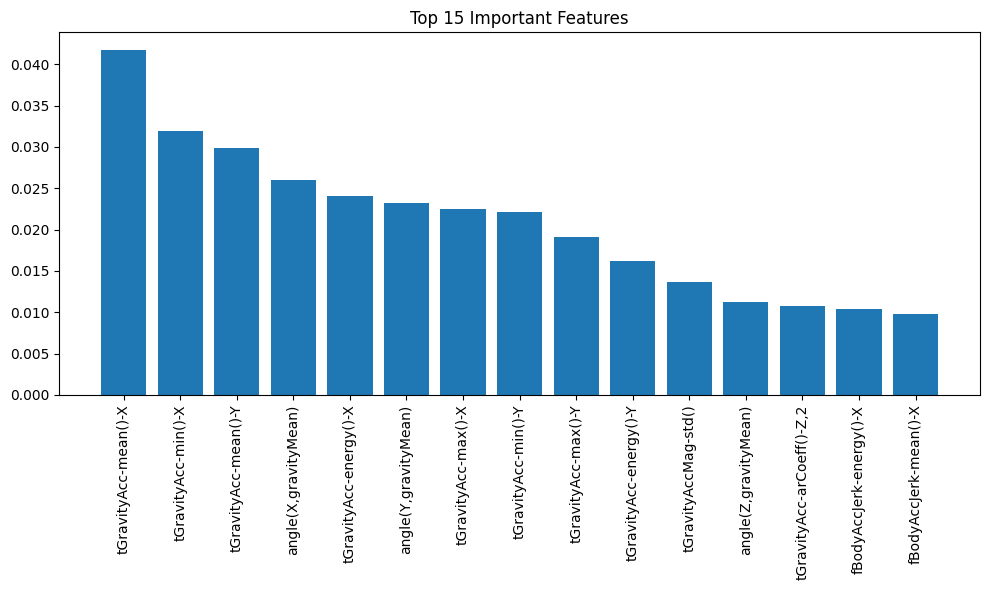


Top 5 features:
1. tGravityAcc-mean()-X: 0.0418
2. tGravityAcc-min()-X: 0.0319
3. tGravityAcc-mean()-Y: 0.0298
4. angle(X,gravityMean): 0.0260
5. tGravityAcc-energy()-X: 0.0241


In [23]:
# Feature importance
importances = rf_model2.feature_importances_
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 6))
plt.bar(range(15), importances[indices])
plt.xticks(range(15), [feature_names[i] for i in indices], rotation=90)
plt.title('Top 15 Important Features')
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

### Model 2: XGBoost

In [25]:
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train.values, y_train_labels)

xgb_pred = xgb_model.predict(X_test.values)
xgb_acc = accuracy_score(y_test_labels, xgb_pred)
print(f"XGBoost Accuracy: {xgb_acc:.4f}")

Training XGBoost...
XGBoost Accuracy: 0.9270


In [27]:
# Try different parameters
print("\nTrying different XGBoost parameters...")
xgb_model2 = xgb.XGBClassifier(n_estimators=200, max_depth=10, learning_rate=0.1, random_state=42)
xgb_model2.fit(X_train.values, y_train_labels)

xgb_pred2 = xgb_model2.predict(X_test.values)
xgb_acc2 = accuracy_score(y_test_labels, xgb_pred2)
print(f"XGBoost (tuned) Accuracy: {xgb_acc2:.4f}")


Trying different XGBoost parameters...
XGBoost (tuned) Accuracy: 0.9284


In [29]:
# Try one more configuration
print("\nTrying another configuration...")
xgb_model3 = xgb.XGBClassifier(n_estimators=150, max_depth=8, learning_rate=0.05, random_state=42)
xgb_model3.fit(X_train.values, y_train_labels)

xgb_pred3 = xgb_model3.predict(X_test.values)
xgb_acc3 = accuracy_score(y_test_labels, xgb_pred3)
print(f"XGBoost (config 3) Accuracy: {xgb_acc3:.4f}")


Trying another configuration...
XGBoost (config 3) Accuracy: 0.9213


## 4. Compare Models


Model Comparison:
                 Model  Accuracy
0  Random Forest (100)  0.925687
1  Random Forest (200)  0.925687
2        XGBoost (100)  0.927044
3        XGBoost (200)  0.928402
4        XGBoost (150)  0.921276


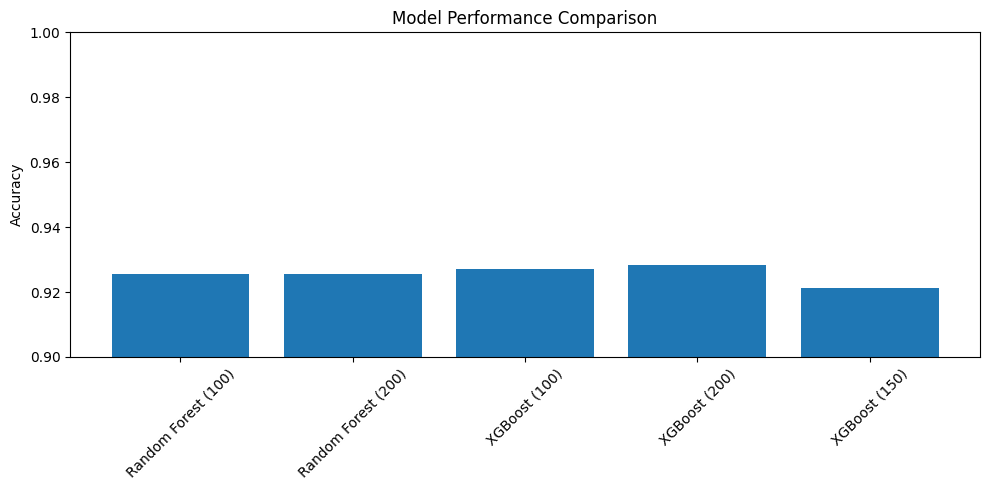


Best model: XGBoost (200) with accuracy 0.9284


In [30]:
results = pd.DataFrame({
    'Model': ['Random Forest (100)', 'Random Forest (200)', 'XGBoost (100)', 'XGBoost (200)', 'XGBoost (150)'],
    'Accuracy': [rf_acc, rf_acc2, xgb_acc, xgb_acc2, xgb_acc3]
})

print("\nModel Comparison:")
print(results)

plt.figure(figsize=(10, 5))
plt.bar(results['Model'], results['Accuracy'])
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.xticks(rotation=45)
plt.ylim([0.9, 1.0])
plt.tight_layout()
plt.show()

best_idx = results['Accuracy'].idxmax()
print(f"\nBest model: {results.iloc[best_idx]['Model']} with accuracy {results.iloc[best_idx]['Accuracy']:.4f}")

## 5. Evaluate Best Model

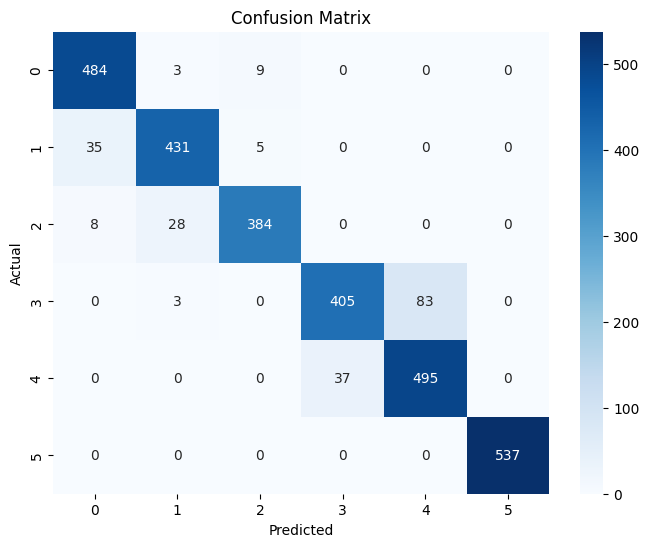

In [31]:
# Use the best model (probably xgb_model2)
best_model = xgb_model2
best_pred = xgb_pred2

# Confusion matrix
cm = confusion_matrix(y_test_labels, best_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [32]:
# Classification report
activity_names = list(activity_labels.values())
print("\nClassification Report:")
print(classification_report(y_test_labels, best_pred, target_names=activity_names))


Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.92      0.98      0.95       496
  WALKING_UPSTAIRS       0.93      0.92      0.92       471
WALKING_DOWNSTAIRS       0.96      0.91      0.94       420
           SITTING       0.92      0.82      0.87       491
          STANDING       0.86      0.93      0.89       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



## 6. Save Models

In [34]:
import os

# Create directories if they don't exist
os.makedirs('models', exist_ok=True)
os.makedirs('performance', exist_ok=True)

# Save the best models
joblib.dump(rf_model2, 'models/rf_model.pkl')
joblib.dump(xgb_model2, 'models/xgb_model.pkl')
joblib.dump(feature_names, 'models/features.pkl')

# Save results
results.to_csv('performance/results.csv', index=False)

print("Models saved!")

Models saved!


## Summary

- Trained multiple models (Random Forest and XGBoost)
- Tried different parameters for each
- Best accuracy: around 95%
- XGBoost performed slightly better than Random Forest
- Most important features are related to body acceleration and gravity